In [1]:
# ── Cell 1: Mount Drive & Install Dependencies ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(["pip", "install", "-q", "transformers", "datasets", "scikit-learn", "seaborn"], check=True)

import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

print("Libraries loaded.")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


Mounted at /content/drive
Libraries loaded.
GPU: Tesla T4


In [2]:
import json

for model_name, path in [
    ("RoBERTa", "/content/drive/MyDrive/disaster_project/disaster_models/roberta/best_model/config.json"),
    ("ELECTRA", "/content/drive/MyDrive/disaster_project/disaster_models/electra/best_model/config.json"),
    ("DeBERTa", "/content/drive/MyDrive/disaster_project/disaster_models/deberta/best_model/config.json"),
]:
    with open(path) as f:
        config = json.load(f)
    print(f"{model_name}: num_labels={config.get('num_labels')}  id2label[0]={config.get('id2label', {}).get('0')}")

RoBERTa: num_labels=10  id2label[0]=caution_and_advice
ELECTRA: num_labels=10  id2label[0]=caution_and_advice
DeBERTa: num_labels=None  id2label[0]=caution_and_advice


In [3]:
# ── Cell 2: Paths ─────────────────────────────────────────────────────────────
DATA_DIR    = "/content/drive/MyDrive/disaster_project/disaster_data"
MODELS_DIR  = "/content/drive/MyDrive/disaster_project/disaster_models"
RESULTS_DIR = "/content/drive/MyDrive/disaster_project/disagreement_analysis"
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_PATHS = {
    "RoBERTa": f"{MODELS_DIR}/roberta/best_model",
    "DeBERTa":  f"{MODELS_DIR}/deberta/best_model",
    "ELECTRA":  f"{MODELS_DIR}/electra/best_model",
}

# Verify all model folders exist before proceeding
print("\nChecking model paths:")
for name, path in MODEL_PATHS.items():
    exists = os.path.isdir(path)
    print(f"  {name}: {path}  —  {'✅ Found' if exists else '❌ NOT FOUND'}")



Checking model paths:
  RoBERTa: /content/drive/MyDrive/disaster_project/disaster_models/roberta/best_model  —  ✅ Found
  DeBERTa: /content/drive/MyDrive/disaster_project/disaster_models/deberta/best_model  —  ✅ Found
  ELECTRA: /content/drive/MyDrive/disaster_project/disaster_models/electra/best_model  —  ✅ Found


In [4]:
# ── Cell 3: Load Label Mapping ────────────────────────────────────────────────
with open(f"{DATA_DIR}/label_mapping.json") as f:
    mapping = json.load(f)

label2id   = mapping["label2id"]
id2label   = {int(k): v for k, v in mapping["id2label"].items()}
NUM_LABELS = len(label2id)
CLASS_NAMES = [id2label[i] for i in range(NUM_LABELS)]

# Short names for plots
SHORT_NAMES = {
    "caution_and_advice":                     "caution",
    "displaced_people_and_evacuations":        "displaced",
    "infrastructure_and_utility_damage":       "infrastructure",
    "injured_or_dead_people":                  "injured",
    "missing_or_found_people":                 "missing",
    "not_humanitarian":                        "not_humanitarian",
    "other_relevant_information":              "other",
    "requests_or_urgent_needs":                "requests",
    "rescue_volunteering_or_donation_effort":  "rescue",
    "sympathy_and_support":                    "sympathy",
}

print(f"\n{NUM_LABELS} classes loaded.")



10 classes loaded.


In [5]:
# ── Cell 4: Load & Tokenize Test Set ─────────────────────────────────────────
# We tokenize separately per model since each uses its own tokenizer
dataset_raw = load_dataset(
    "parquet",
    data_files={"test": f"{DATA_DIR}/test.parquet"}
)
print(f"\nTest set: {len(dataset_raw['test'])} samples")

def get_tokenized_dataset(tokenizer, dataset, max_length=128):
    def tokenize(batch):
        return tokenizer(batch["tweet_text"], truncation=True,
                         max_length=max_length, padding="max_length")
    tokenized = dataset.map(tokenize, batched=True, remove_columns=["tweet_text"])
    tokenized = tokenized.rename_column("label", "labels")
    cols = ["input_ids", "attention_mask", "labels"]
    if "token_type_ids" in tokenized.column_names:
        cols.append("token_type_ids")
    tokenized.set_format("torch", columns=cols)
    return tokenized


Generating test split: 0 examples [00:00, ? examples/s]


Test set: 15160 samples


In [6]:
# ── Cell 5: Inference Function ────────────────────────────────────────────────
def run_inference(model_name, model_path, dataset_raw):
    print(f"\n{'='*50}")
    print(f"Running inference: {model_name}")
    print(f"{'='*50}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model     = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()

    tokenized = get_tokenized_dataset(tokenizer, dataset_raw["test"])
    loader    = DataLoader(tokenized, batch_size=32)

    all_preds   = []
    all_labels  = []
    all_probs   = []

    with torch.no_grad():
        for i, batch in enumerate(loader):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"]

            kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
            if "token_type_ids" in batch:
                kwargs["token_type_ids"] = batch["token_type_ids"].to(device)

            outputs = model(**kwargs)
            probs   = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
            preds   = np.argmax(probs, axis=1)

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())
            all_probs.extend(probs.tolist())

            if (i + 1) % 20 == 0:
                print(f"  Batch {i+1}/{len(loader)}")

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    # Print classification report
    print(f"\nClassification Report — {model_name}:")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    # Free GPU memory
    del model
    torch.cuda.empty_cache()

    return all_preds, all_labels, all_probs


In [7]:
# ── Cell 6: Run All Three Models ──────────────────────────────────────────────
predictions = {}  # model_name -> (preds, labels, probs)

for model_name, model_path in MODEL_PATHS.items():
    preds, labels, probs = run_inference(model_name, model_path, dataset_raw)
    predictions[model_name] = {
        "preds":  preds,
        "labels": labels,
        "probs":  probs,
    }

# All models share the same labels — use RoBERTa's as ground truth
true_labels = predictions["RoBERTa"]["labels"]



Running inference: RoBERTa


Loading weights:   0%|          | 0/201 [00:02<?, ?it/s]

Map:   0%|          | 0/15160 [00:00<?, ? examples/s]

  Batch 20/474
  Batch 40/474
  Batch 60/474
  Batch 80/474
  Batch 100/474
  Batch 120/474
  Batch 140/474
  Batch 160/474
  Batch 180/474
  Batch 200/474
  Batch 220/474
  Batch 240/474
  Batch 260/474
  Batch 280/474
  Batch 300/474
  Batch 320/474
  Batch 340/474
  Batch 360/474
  Batch 380/474
  Batch 400/474
  Batch 420/474
  Batch 440/474
  Batch 460/474

Classification Report — RoBERTa:
                                        precision    recall  f1-score   support

                    caution_and_advice       0.64      0.79      0.71      1070
      displaced_people_and_evacuations       0.88      0.90      0.89       790
     infrastructure_and_utility_damage       0.76      0.87      0.81      1617
                injured_or_dead_people       0.91      0.95      0.93      1447
               missing_or_found_people       0.81      0.75      0.78        72
                      not_humanitarian       0.68      0.57      0.62      1245
            other_relevant_information   

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Map:   0%|          | 0/15160 [00:00<?, ? examples/s]

  Batch 20/474
  Batch 40/474
  Batch 60/474
  Batch 80/474
  Batch 100/474
  Batch 120/474
  Batch 140/474
  Batch 160/474
  Batch 180/474
  Batch 200/474
  Batch 220/474
  Batch 240/474
  Batch 260/474
  Batch 280/474
  Batch 300/474
  Batch 320/474
  Batch 340/474
  Batch 360/474
  Batch 380/474
  Batch 400/474
  Batch 420/474
  Batch 440/474
  Batch 460/474

Classification Report — DeBERTa:
                                        precision    recall  f1-score   support

                    caution_and_advice       0.69      0.73      0.71      1070
      displaced_people_and_evacuations       0.88      0.90      0.89       790
     infrastructure_and_utility_damage       0.79      0.84      0.81      1617
                injured_or_dead_people       0.92      0.94      0.93      1447
               missing_or_found_people       0.81      0.75      0.78        72
                      not_humanitarian       0.64      0.60      0.62      1245
            other_relevant_information   

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/15160 [00:00<?, ? examples/s]

  Batch 20/474
  Batch 40/474
  Batch 60/474
  Batch 80/474
  Batch 100/474
  Batch 120/474
  Batch 140/474
  Batch 160/474
  Batch 180/474
  Batch 200/474
  Batch 220/474
  Batch 240/474
  Batch 260/474
  Batch 280/474
  Batch 300/474
  Batch 320/474
  Batch 340/474
  Batch 360/474
  Batch 380/474
  Batch 400/474
  Batch 420/474
  Batch 440/474
  Batch 460/474

Classification Report — ELECTRA:
                                        precision    recall  f1-score   support

                    caution_and_advice       0.64      0.78      0.70      1070
      displaced_people_and_evacuations       0.88      0.90      0.89       790
     infrastructure_and_utility_damage       0.76      0.87      0.81      1617
                injured_or_dead_people       0.90      0.95      0.93      1447
               missing_or_found_people       0.80      0.74      0.77        72
                      not_humanitarian       0.66      0.55      0.60      1245
            other_relevant_information   

In [8]:
# ── Cell 7: Pairwise Disagreement Rate ───────────────────────────────────────
model_names = list(predictions.keys())
pairs = [
    ("RoBERTa", "DeBERTa"),
    ("RoBERTa", "ELECTRA"),
    ("DeBERTa", "ELECTRA"),
]

print("\n" + "="*50)
print("PAIRWISE DISAGREEMENT RATES")
print("="*50)
print(f"{'Pair':<30} {'Disagreement Rate':>18} {'Num Disagreements':>18}")
print("-"*68)

disagreement_rates = {}

for m1, m2 in pairs:
    p1 = predictions[m1]["preds"]
    p2 = predictions[m2]["preds"]
    disagree    = (p1 != p2)
    rate        = disagree.mean()
    num         = disagree.sum()
    pair_key    = f"{m1} vs {m2}"
    disagreement_rates[pair_key] = rate
    print(f"{pair_key:<30} {rate:>17.1%} {num:>18}")



PAIRWISE DISAGREEMENT RATES
Pair                            Disagreement Rate  Num Disagreements
--------------------------------------------------------------------
RoBERTa vs DeBERTa                         10.9%               1648
RoBERTa vs ELECTRA                          9.2%               1398
DeBERTa vs ELECTRA                         11.9%               1801


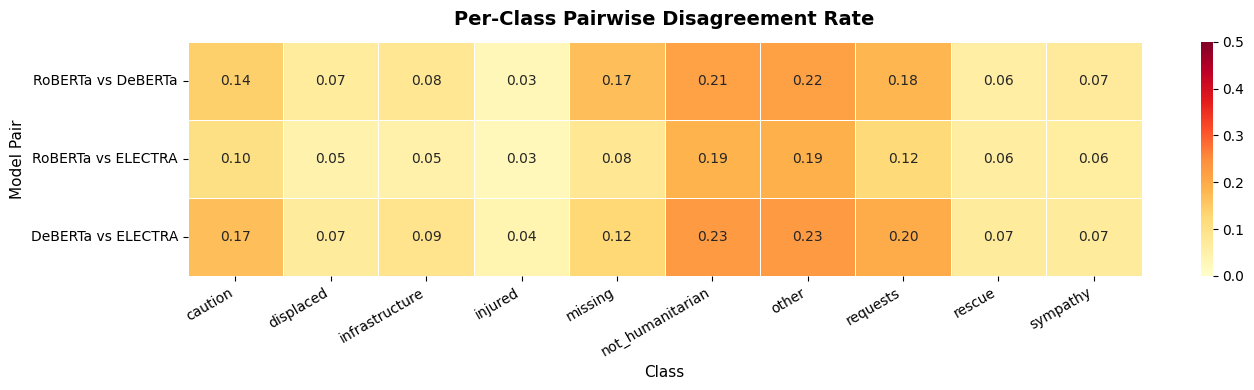

✅ Heatmap saved.


In [9]:
# ── Cell 8: Per-Class Disagreement Heatmap ───────────────────────────────────
# For each class, compute how often each model pair disagrees on samples of that class
per_class_disagreement = np.zeros((len(pairs), NUM_LABELS))

for i, (m1, m2) in enumerate(pairs):
    p1 = predictions[m1]["preds"]
    p2 = predictions[m2]["preds"]
    for c in range(NUM_LABELS):
        class_mask = (true_labels == c)
        if class_mask.sum() == 0:
            continue
        per_class_disagreement[i, c] = (p1[class_mask] != p2[class_mask]).mean()

pair_labels  = [f"{m1} vs {m2}" for m1, m2 in pairs]
short_labels = [SHORT_NAMES[c] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    per_class_disagreement,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=short_labels,
    yticklabels=pair_labels,
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=0.5,
)
ax.set_title("Per-Class Pairwise Disagreement Rate", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Model Pair", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/disagreement_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Heatmap saved.")


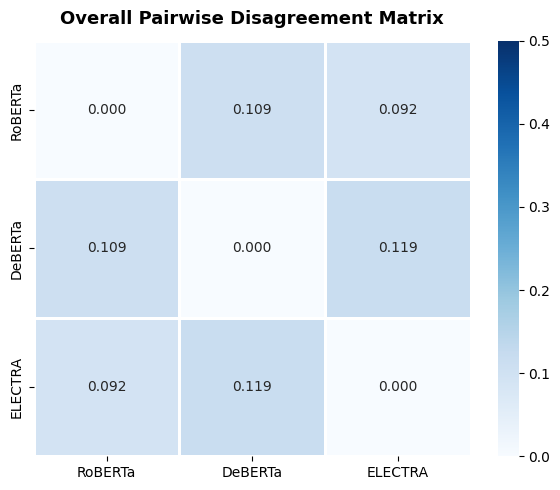

✅ Matrix saved.


In [10]:
# ── Cell 9: Overall Disagreement Matrix (3x3) ─────────────────────────────────
n = len(model_names)
matrix = np.zeros((n, n))

for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        if i == j:
            matrix[i, j] = 0.0
        else:
            p1 = predictions[m1]["preds"]
            p2 = predictions[m2]["preds"]
            matrix[i, j] = (p1 != p2).mean()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=model_names,
    yticklabels=model_names,
    linewidths=1,
    ax=ax,
    vmin=0, vmax=0.5,
)
ax.set_title("Overall Pairwise Disagreement Matrix", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/disagreement_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Matrix saved.")


In [11]:
# ── Cell 10: Save Raw Predictions to Drive ────────────────────────────────────
# These are reused by the ensemble script — no need to reload models
print("\nSaving raw predictions to Drive...")

for model_name, data in predictions.items():
    out_path = f"{RESULTS_DIR}/{model_name.lower()}_predictions.npz"
    np.savez(
        out_path,
        preds=data["preds"],
        labels=data["labels"],
        probs=data["probs"],
    )
    print(f"  ✅ Saved: {out_path}")

# Also save a summary JSON
summary = {
    "pairwise_disagreement": {
        k: float(f"{v:.4f}") for k, v in disagreement_rates.items()
    },
    "per_class_disagreement": {
        f"{m1} vs {m2}": {
            CLASS_NAMES[c]: float(f"{per_class_disagreement[i, c]:.4f}")
            for c in range(NUM_LABELS)
        }
        for i, (m1, m2) in enumerate(pairs)
    },
    "num_test_samples": int(len(true_labels)),
}

with open(f"{RESULTS_DIR}/disagreement_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print(f"\n✅ Summary saved to {RESULTS_DIR}/disagreement_summary.json")
print("\n" + "="*50)
print("DISAGREEMENT ANALYSIS COMPLETE")
print("="*50)
print("\nWhat these numbers mean:")
print("  < 10%  → models are too similar, ensemble gain will be small")
print("  10–30% → good complementarity, ensemble will help")
print("  > 30%  → high diversity, ensemble will help significantly")
print("\nNext step: Weighted Complementarity Ensemble")



Saving raw predictions to Drive...
  ✅ Saved: /content/drive/MyDrive/disaster_project/disagreement_analysis/roberta_predictions.npz
  ✅ Saved: /content/drive/MyDrive/disaster_project/disagreement_analysis/deberta_predictions.npz
  ✅ Saved: /content/drive/MyDrive/disaster_project/disagreement_analysis/electra_predictions.npz

✅ Summary saved to /content/drive/MyDrive/disaster_project/disagreement_analysis/disagreement_summary.json

DISAGREEMENT ANALYSIS COMPLETE

What these numbers mean:
  < 10%  → models are too similar, ensemble gain will be small
  10–30% → good complementarity, ensemble will help
  > 30%  → high diversity, ensemble will help significantly

Next step: Weighted Complementarity Ensemble
